In [7]:
import numpy as np
from scipy.constants import R
import matplotlib.pyplot as plt

from LJ_gas import (
    ParticleSystem, SimulationParameters,
    simulate_NVT_step, initialize_positions, initialize_velocities,
    calculate_force, potential_energy, kinetic_energy,
    instantaneous_temperature, density,
)

# argon params
mass_argon = 39.95
sigma_argon = 0.34            # nm
epsilon_argon = 120 * R * 1e-3   # kJ/mol

print("imports ok")

imports ok


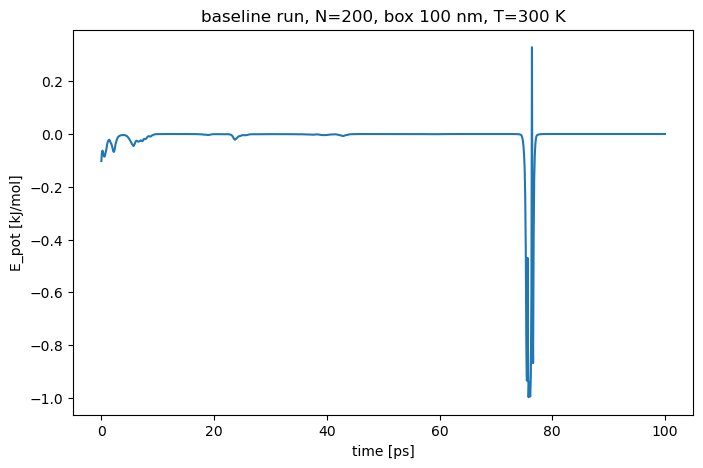

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# load the energy data the run saved. columns: E_pot, E_kin, T, P
ene = np.load("baseline_ene.npy")

dt = 0.1  # ps, same as in the run script
t = np.arange(ene.shape[0]) * dt  # time axis

# potential energy, no forced y limits this time
plt.figure(figsize=(8, 5))
plt.plot(t, ene[:, 0])
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("baseline run, N=200, box 100 nm, T=300 K")
plt.savefig("baseline_Epot_clean.png", dpi=200, bbox_inches="tight")
plt.show()

baseline run at defaults. E_pot sits at ~0 almost the whole time because the box
is huge and particles rarely meet. spikes = rare close encounters. not exploding,
not flat from being broken - flat because dilute..


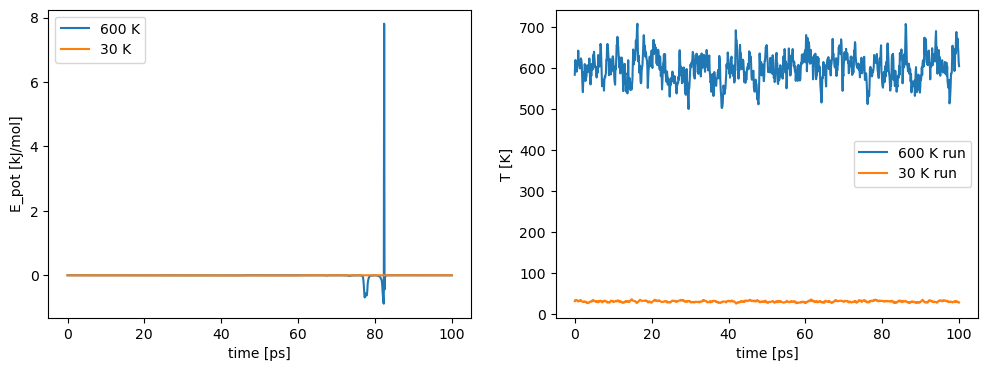

In [9]:
# compare E_pot for hot vs cold run
hot = np.load("hot_600K_ene.npy")
cold = np.load("cold_30K_ene.npy")
t = np.arange(hot.shape[0]) * 0.1  # ps

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, hot[:, 0], label="600 K")
ax[0].plot(t, cold[:, 0], label="30 K")
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("E_pot [kJ/mol]")
ax[0].legend()

# temperature check - did the thermostat actually hold the targets
ax[1].plot(t, hot[:, 2], label="600 K run")
ax[1].plot(t, cold[:, 2], label="30 K run")
ax[1].set_xlabel("time [ps]")
ax[1].set_ylabel("T [K]")
ax[1].legend()

plt.savefig("hot_vs_cold.png", dpi=200, bbox_inches="tight")
plt.show()

hot 600 K vs cold 30 K at default density. E_pot flat at 0 for both, one lucky
collision in the hot run at ~82 ps. no clumping even at 30 K (argon boils at 87 K)
because the box is 100000x too dilute - particles never find each other.
thermostat confirmed working: T holds at both targets, bigger fluctuations at
600 K which is expected (fluctuation size scales with T).
conclusion for the project: condensation needs higher density. temperature alone
does nothing at this density

# phase 3 - cooling protocol

changes vs baseline: eps x3 (project hint), box 6 nm instead of 100 (density fix
from phase 2), dt 0.005 ps (dense system + stronger eps needs smaller timestep).
with eps x3, T* = T/360. plan: start ~400 K (T* 1.1, gas) and step down to
40 K (T* 0.11) in stages. snapshot positions at each stage, record E_pot every step.

In [11]:
def initialize_positions_lattice(ps, box_length):
    # put particles on a cubic grid so nothing starts overlapping.
    # random init in a small box = particles on top of each other = boom
    n_side = int(np.ceil(ps.n ** (1/3)))        # grid points per side (6 for 200)
    spacing = box_length / n_side               # 1 nm apart, ~3 sigma, safe
    points = []
    for ix in range(n_side):
        for iy in range(n_side):
            for iz in range(n_side):
                points.append([(ix + 0.5) * spacing,
                               (iy + 0.5) * spacing,
                               (iz + 0.5) * spacing])
    ps.position[:] = np.array(points[:ps.n])

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import R
from LJ_gas import (ParticleSystem, SimulationParameters, simulate_NVT_step,
                    initialize_positions, initialize_velocities,
                    calculate_force, potential_energy, instantaneous_temperature)

# system - denser box, beefed up epsilon
n_particles = 200
mass = 39.95
sigma = 0.34
epsilon = 3 * 120 * R * 1e-3   # 3x default. eps/kB now 360 K

box_length = 6.0     # nm. this is the density fix
dt = 0.005           # ps. small because dense + strong eps
steps_per_stage = 2000

# cooling schedule in K. T* = T/360
schedule = [400, 300, 220, 160, 120, 90, 60, 40]

sim = SimulationParameters(dt=dt, n_steps=steps_per_stage,
                           temperature=schedule[0],
                           box_length=box_length,
                           tau_thermostat=1, rij_min=1e-2)

ps = ParticleSystem(n_particles)
for i in range(n_particles):
    ps.set_parameters(i, mass=mass, sigma=sigma, epsilon=epsilon)

initialize_positions_lattice(ps, sim.box_length)
initialize_velocities(ps, sim.temperature)
calculate_force(ps, sim)

print("T* schedule:", [round(T/360, 2) for T in schedule])

T* schedule: [1.11, 0.83, 0.61, 0.44, 0.33, 0.25, 0.17, 0.11]


In [13]:
# cooling loop. lower the thermostat target stage by stage, run, snapshot
epot_trace = []       # E_pot every step, whole run
temp_trace = []       # actual T every step, to see the system chasing the target
snapshots = []        # positions at the end of each stage

for T_target in schedule:
    sim.temperature = T_target   # thermostat now pulls toward the new T
    for step in range(steps_per_stage):
        simulate_NVT_step(ps, sim)
        epot_trace.append(potential_energy(ps, sim))
        temp_trace.append(instantaneous_temperature(ps))
    snapshots.append(ps.position.copy())   # .copy() or every snapshot ends up identical
    print(f"stage {T_target} K done, E_pot = {epot_trace[-1]:.1f} kJ/mol")

epot_trace = np.array(epot_trace)
temp_trace = np.array(temp_trace)
np.save("cooling_epot.npy", epot_trace)
np.save("cooling_snapshots.npy", np.array(snapshots))

stage 400 K done, E_pot = -206.5 kJ/mol
stage 300 K done, E_pot = -274.1 kJ/mol
stage 220 K done, E_pot = -343.5 kJ/mol
stage 160 K done, E_pot = -699.1 kJ/mol
stage 120 K done, E_pot = -1186.6 kJ/mol
stage 90 K done, E_pot = -1545.3 kJ/mol
stage 60 K done, E_pot = -1810.4 kJ/mol
stage 40 K done, E_pot = -1976.4 kJ/mol


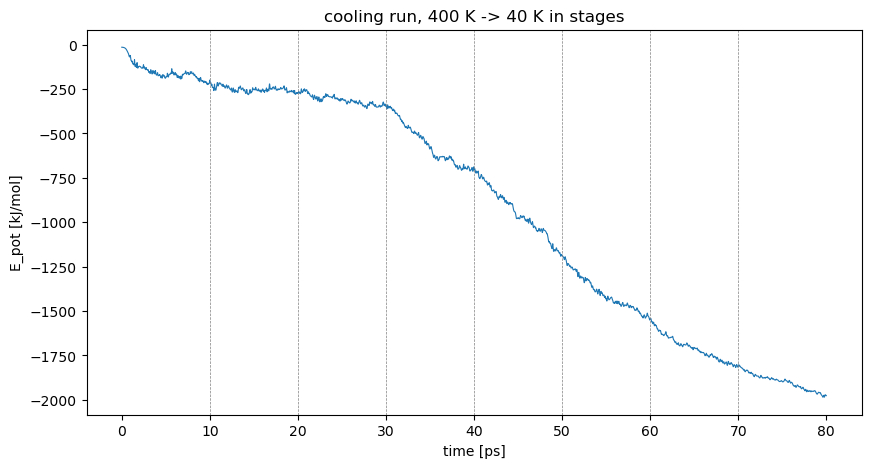

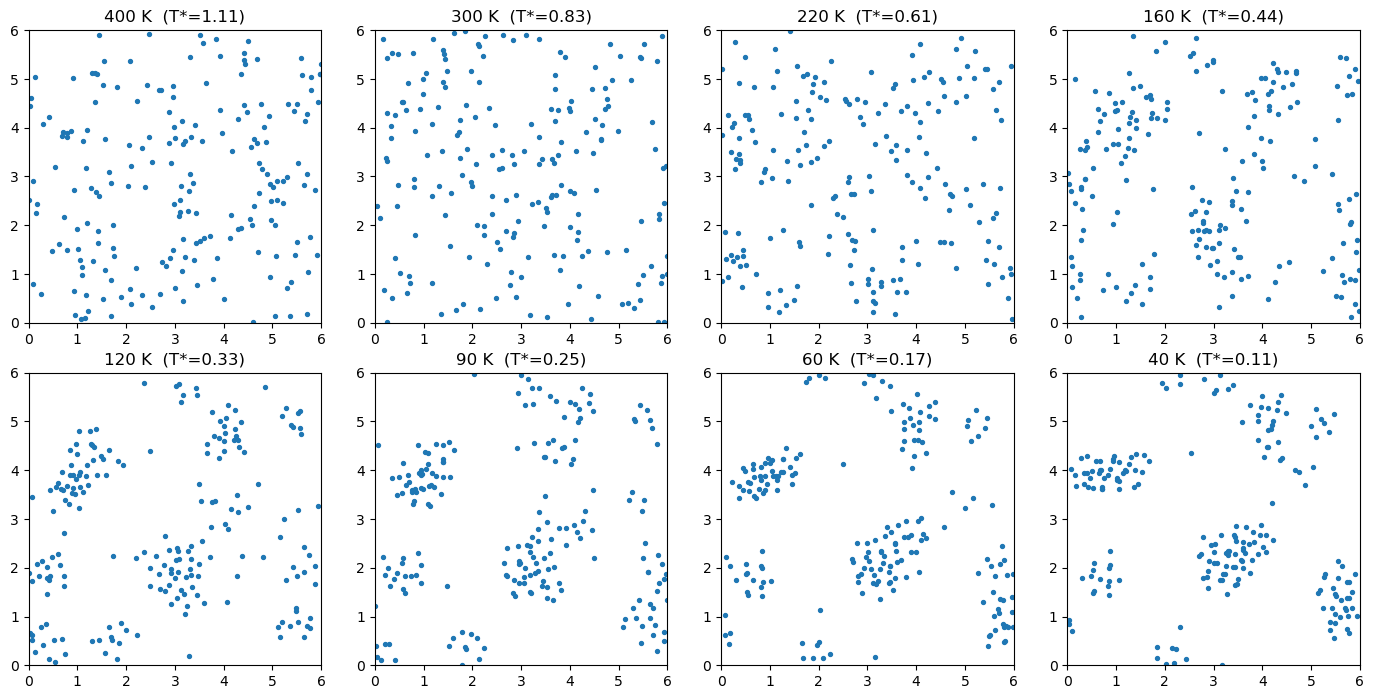

In [14]:
# full E_pot trace with stage boundaries
t = np.arange(len(epot_trace)) * dt
plt.figure(figsize=(10, 5))
plt.plot(t, epot_trace, lw=0.8)
for k in range(1, len(schedule)):
    plt.axvline(k * steps_per_stage * dt, color="gray", ls="--", lw=0.5)
plt.xlabel("time [ps]")
plt.ylabel("E_pot [kJ/mol]")
plt.title("cooling run, 400 K -> 40 K in stages")
plt.savefig("cooling_epot.png", dpi=200, bbox_inches="tight")
plt.show()

# snapshots - xy projection at each stage
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for k, ax in enumerate(axes.flat):
    pos = snapshots[k]
    ax.scatter(pos[:, 0], pos[:, 1], s=8)
    ax.set_title(f"{schedule[k]} K  (T*={schedule[k]/360:.2f})")
    ax.set_xlim(0, box_length); ax.set_ylim(0, box_length)
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("cooling_snapshots.png", dpi=200, bbox_inches="tight")
plt.show()